In [7]:
import pandas as pd
import numpy as np
df_final = pd.read_csv("../data/processed/cleaned_beja.csv")
df_final['Date'] = pd.to_datetime(df_final['Date'])

print(df_final.shape)

(667, 11)


In [8]:
# ============================================
# PHENOLOGY CONFIG — change values here only
# ============================================

# % of each plot's own min-max NDVI range used to define SOS/EOS crossing points
# e.g. 0.20 = SOS/EOS occur where NDVI crosses 20% of the way from min to max
PHENOLOGY_AMPLITUDE_THRESHOLD = 0.20

# minimum number of data points required in a plot's timeline to attempt
# phenology extraction (very short series make SOS/EOS unreliable)
PHENOLOGY_MIN_POINTS = 8

# column used as the vegetation signal for phenology extraction
PHENOLOGY_TARGET_COLUMN = 'NDVI'

print("Phenology config loaded:")
print(f"  Amplitude threshold: {PHENOLOGY_AMPLITUDE_THRESHOLD}")
print(f"  Minimum points required: {PHENOLOGY_MIN_POINTS}")
print(f"  Target column: {PHENOLOGY_TARGET_COLUMN}")

Phenology config loaded:
  Amplitude threshold: 0.2
  Minimum points required: 8
  Target column: NDVI


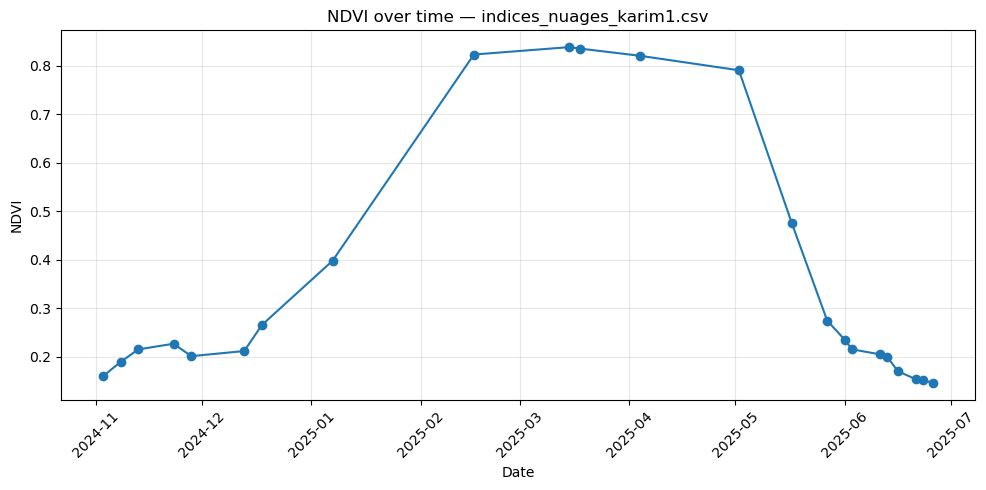

          Date      NDVI
253 2024-11-03  0.159225
254 2024-11-08  0.188904
255 2024-11-13  0.214708
256 2024-11-23  0.226417
257 2024-11-28  0.200803
258 2024-12-13  0.211336
259 2024-12-18  0.265123
260 2025-01-07  0.397648
261 2025-02-16  0.823237
262 2025-03-15  0.838521
263 2025-03-18  0.835538
264 2025-04-04  0.820660
265 2025-05-02  0.790790
266 2025-05-17  0.474788
267 2025-05-27  0.273990
268 2025-06-01  0.234380
269 2025-06-03  0.214848
270 2025-06-11  0.204437
271 2025-06-13  0.199000
272 2025-06-16  0.169809
273 2025-06-21  0.153311
274 2025-06-23  0.151353
275 2025-06-26  0.145523


In [9]:
import matplotlib.pyplot as plt

# pick one plot to look at first - karim1 has a decent number of points
sample_file = 'indices_nuages_karim1.csv'
sample = df_final[df_final['source_file'] == sample_file].sort_values('Date')

plt.figure(figsize=(10, 5))
plt.plot(sample['Date'], sample['NDVI'], marker='o')
plt.title(f'NDVI over time — {sample_file}')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(sample[['Date', 'NDVI']].to_string())

In [14]:
def extract_phenology(group, amplitude_threshold=PHENOLOGY_AMPLITUDE_THRESHOLD, 
                        min_points=PHENOLOGY_MIN_POINTS, target_col=PHENOLOGY_TARGET_COLUMN):
    """
    Given one plot's timeline, returns SOS, POS, EOS, LOS, AUC.
    """
    group = group.sort_values('Date').reset_index(drop=True)
    
    # safety check: not enough points to trust the result
    if len(group) < min_points:
        return pd.Series({'SOS': None, 'POS': None, 'EOS': None, 'LOS': None, 'AUC': None,
                           'phenology_note': f'skipped — only {len(group)} points'})
    
    values = group[target_col].values
    dates = group['Date'].values
    
    min_val, max_val = values.min(), values.max()
    threshold = min_val + amplitude_threshold * (max_val - min_val)
    
    # POS = date of maximum value
    pos_idx = values.argmax()
    pos_date = dates[pos_idx]
    
    # SOS: scan forward from the start, find first crossing above threshold, before POS
    sos_date = None
    for i in range(1, pos_idx + 1):
        if values[i-1] < threshold <= values[i]:
            sos_date = dates[i]
            break
    
    # EOS: scan forward from POS, find first crossing below threshold, after POS
    eos_date = None
    for i in range(pos_idx + 1, len(values)):
        if values[i-1] >= threshold > values[i]:
            eos_date = dates[i]
            break
    
    # LOS and AUC only make sense if both SOS and EOS were found
    los_days = None
    auc = None
    if sos_date is not None and eos_date is not None:
        los_days = (pd.Timestamp(eos_date) - pd.Timestamp(sos_date)).days
        season_mask = (dates >= sos_date) & (dates <= eos_date)
        auc = np.trapezoid(values[season_mask], 
                        x=pd.to_datetime(dates[season_mask]).astype('int64') / 1e9 / 86400)
    
    return pd.Series({
        'SOS': sos_date, 'POS': pos_date, 'EOS': eos_date,
        'LOS': los_days, 'AUC': auc, 
        'phenology_note': 'ok' if (sos_date is not None and eos_date is not None) 
                           else 'incomplete — SOS or EOS not found within data range'
    })

In [15]:
phenology_results = df_final.groupby('source_file', group_keys=True).apply(
    extract_phenology, include_groups=False
)
phenology_results = phenology_results.reset_index()

# attach variety for readability (one variety per source_file, so just grab the first)
variety_lookup = df_final.groupby('source_file')['variety'].first()
phenology_results['variety'] = phenology_results['source_file'].map(variety_lookup)

# reorder columns nicely
phenology_results = phenology_results[
    ['source_file', 'variety', 'SOS', 'POS', 'EOS', 'LOS', 'AUC', 'phenology_note']
]

print(phenology_results.to_string())

                      source_file   variety        SOS        POS        EOS    LOS         AUC                                       phenology_note
0      indices_nuages_carioka.csv   carioka 2024-11-08 2025-04-04        NaT    NaN         NaN  incomplete — SOS or EOS not found within data range
1      indices_nuages_dhahbi2.csv    dhahbi 2025-01-07 2025-04-04 2025-05-17  130.0  102.085913                                                   ok
2      indices_nuages_dhahbi3.csv    dhahbi 2024-12-13 2025-04-04 2025-06-01  170.0  118.299209                                                   ok
3      indices_nuages_dhahbi4.csv    dhahbi 2024-12-13 2025-04-04 2025-06-03  172.0  124.463335                                                   ok
4      indices_nuages_dhahbi5.csv    dhahbi 2024-12-18 2025-04-04 2025-05-27  160.0  106.344276                                                   ok
5      indices_nuages_dhahbi6.csv    dhahbi 2024-12-18 2025-04-04 2025-05-27  160.0  111.018716           

In [16]:
print(f"Total plots: {len(phenology_results)}")
print(f"\nNote breakdown:\n{phenology_results['phenology_note'].value_counts()}")

print(f"\nLOS summary (days):")
print(phenology_results['LOS'].describe())

print(f"\nIncomplete plots:")
print(phenology_results[phenology_results['phenology_note'] != 'ok'])

Total plots: 29

Note breakdown:
phenology_note
ok                                                     28
incomplete — SOS or EOS not found within data range     1
Name: count, dtype: int64

LOS summary (days):
count     28.000000
mean     161.000000
std       18.646815
min      115.000000
25%      158.750000
50%      160.000000
75%      167.750000
max      200.000000
Name: LOS, dtype: float64

Incomplete plots:
                  source_file  variety        SOS        POS EOS  LOS  AUC  \
0  indices_nuages_carioka.csv  carioka 2024-11-08 2025-04-04 NaT  NaN  NaN   

                                      phenology_note  
0  incomplete — SOS or EOS not found within data ...  


In [17]:
phenology_results.to_csv("../reports/phenology_metrics.csv", index=False)
print("Saved phenology metrics.")

Saved phenology metrics.
